In [8]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# colores
turquesa = '\033[38;5;44m'
reset = '\033[0m'

# Configuración de visualización
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')

# Verificar versiones
print(f"{turquesa}Pandas versión:{reset} {pd.__version__}")
print(f"{turquesa}NumPy versión:{reset} {np.__version__}")

Pandas versión: 2.3.3
NumPy versión: 2.2.6


## 🟢 Ejercicio 1: Primeros Pasos - Conociendo tus Datos

Carga el siguiente dataset de empleados y realiza una exploración inicial:

```python
rng = np.random.default_rng(42)
df_empleados = pd.DataFrame({
    'nombre': ['Ana', 'Carlos', 'María', 'Pedro', 'Laura', 'Juan', 'Sofía', 'Miguel', 'Elena', 'David'],
    'edad': [28, 35, None, 42, 31, 29, None, 38, 26, 45],
    'departamento': ['Ventas', 'IT', 'Ventas', 'RRHH', 'IT', 'Ventas', 'IT', 'RRHH', 'Marketing', 'IT'],
    'salario': [32000, 45000, 38000, 41000, 52000, 35000, 48000, 39000, 33000, 55000],
    'años_empresa': [2, 8, 5, 12, 4, 3, 6, 9, 1, 15]
})
```

**Tareas:**
1. Muestra las dimensiones del dataset (filas y columnas)
2. Muestra los tipos de datos de cada columna
3. Muestra las primeras 5 filas
4. Usa `.info()` para ver un resumen completo
5. Identifica cuántos valores faltantes hay en cada columna

In [ ]:
# Crear el DataFrame
rng = np.random.default_rng(42)
df_empleados = pd.DataFrame({
    'nombre': ['Ana', 'Carlos', 'María', 'Pedro', 'Laura', 'Juan', 'Sofía', 'Miguel', 'Elena', 'David'],
    'edad': [28, 35, None, 42, 31, 29, None, 38, 26, 45],
    'departamento': ['Ventas', 'IT', 'Ventas', 'RRHH', 'IT', 'Ventas', 'IT', 'RRHH', 'Marketing', 'IT'],
    'salario': [32000, 45000, 38000, 41000, 52000, 35000, 48000, 39000, 33000, 55000],
    'años_empresa': [2, 8, 5, 12, 4, 3, 6, 9, 1, 15]
})

print(f"{turquesa}\nDimensiónes del Dataset (filas y columnas:){reset}", df_empleados.shape)

print(f"{turquesa}\nTipos de datos{reset}")
print(df_empleados.dtypes)

print(f"{turquesa}\nLas primeras 5 filas{reset}")
print(df_empleados.head())

print(f"{turquesa}\nInformación general{reset}")
df_empleados.info()

print(f"{turquesa}\nValores faltantes por columna{reset}")
print(df_empleados.isnull().sum())







Dimensiónes del Dataset (filas y columnas:) (10, 5)

Tipos de datos
nombre           object
edad            float64
departamento     object
salario           int64
años_empresa      int64
dtype: object

Las primeras 5 filas
   nombre  edad departamento  salario  años_empresa
0     Ana  28.0       Ventas    32000             2
1  Carlos  35.0           IT    45000             8
2   María   NaN       Ventas    38000             5
3   Pedro  42.0         RRHH    41000            12
4   Laura  31.0           IT    52000             4

Información general
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   nombre        10 non-null     object 
 1   edad          8 non-null      float64
 2   departamento  10 non-null     object 
 3   salario       10 non-null     int64  
 4   años_empresa  10 non-null     int64  
dtypes: float64(1), int64(2), object(2)


## 🟢 Ejercicio 2: Estadísticas Descriptivas

Usando el dataset de empleados del ejercicio anterior:

**Tareas:**
1. Calcula estadísticas descriptivas de las columnas numéricas con `.describe()`
2. Calcula la media, mediana y desviación estándar del salario
3. Cuenta cuántos empleados hay en cada departamento
4. Calcula el salario medio por departamento
5. Encuentra el empleado con mayor antigüedad

In [23]:
print (f"{turquesa}\nEstadísticas descriptivas generales{reset}") 
print(df_empleados.describe())

print(f"{turquesa}\nMedia del salario: {reset}{df_empleados['salario'].mean():.2f}")
print(f"{turquesa}Mediana del salario: {reset}{df_empleados['salario'].median():.2f}")
print(f"{turquesa}Desviación Estaándar del salario: {reset}{df_empleados['salario'].std():.2f}")

# Número de empleados por departamento
print(f"{turquesa}\nEmpleados por Departamento{reset}")
conteo_dept = df_empleados['departamento'].value_counts()
print(conteo_dept)

# Salario medio por departamente
print(f"{turquesa}\nSalario Medio por Departamento{reset}")
salario_depto = df_empleados.groupby('departamento')['salario'].mean()
print(salario_depto)

# Empleado con mayor antigüedad
# Buscamos el índice del máximo y extraemos la fila
idx_max_antiguedad = df_empleados['años_empresa'].idxmax()
empleado_pro = df_empleados.loc[idx_max_antiguedad]

print(f"{turquesa}\nEmpleado con mayor antigüedad{reset}")
print(f"Nombre:  {empleado_pro['nombre']}")
print(f"Años:  {empleado_pro['años_empresa']}")
print(f"Departamento:  {empleado_pro['departamento']}")


Estadísticas descriptivas generales
            edad       salario  años_empresa
count   8.000000     10.000000     10.000000
mean   34.250000  41800.000000      6.500000
std     6.923046   7955.431408      4.503085
min    26.000000  32000.000000      1.000000
25%    28.750000  35750.000000      3.250000
50%    33.000000  40000.000000      5.500000
75%    39.000000  47250.000000      8.750000
max    45.000000  55000.000000     15.000000

Media del salario: 41800.00
Mediana del salario: 40000.00
Desviación Estaándar del salario: 7955.43

Empleados por Departamento
departamento
IT           4
Ventas       3
RRHH         2
Marketing    1
Name: count, dtype: int64

Salario Medio por Departamento
departamento
IT           50000.0
Marketing    33000.0
RRHH         40000.0
Ventas       35000.0
Name: salario, dtype: float64

Empleado con mayor antigüedad
Nombre:  David
Años:  15
Departamento:  IT


## 🟢 Ejercicio 3: Detección y Tratamiento de Valores Faltantes

Trabaja con el siguiente dataset que tiene varios valores faltantes:

```python
df_nulos = pd.DataFrame({
    'producto': ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H'],
    'precio': [100, None, 150, 120, None, 200, 180, None],
    'stock': [50, 30, None, 45, 60, None, 35, 40],
    'categoria': ['Electrónica', 'Ropa', None, 'Electrónica', 'Ropa', 'Hogar', None, 'Electrónica'],
    'puntuacion': [4.5, 3.8, 4.2, None, 4.0, 4.7, None, 3.9]
})
```

**Tareas:**
1. Identifica el total de valores faltantes por columna
2. Calcula el porcentaje de valores faltantes por columna
3. Rellena los precios faltantes con la **mediana** de los precios
4. Rellena el stock faltante con **0**
5. Rellena la categoría faltante con **'Sin categoría'**
6. Rellena la puntuación faltante con la **media**
7. Verifica que no queden valores faltantes

In [ ]:
# Crear el DataFrame
df_nulos = pd.DataFrame({
    'producto': ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H'],
    'precio': [100, None, 150, 120, None, 200, 180, None],
    'stock': [50, 30, None, 45, 60, None, 35, 40],
    'categoria': ['Electrónica', 'Ropa', None, 'Electrónica', 'Ropa', 'Hogar', None, 'Electrónica'],
    'puntuacion': [4.5, 3.8, 4.2, None, 4.0, 4.7, None, 3.9]
})

print(f"{turquesa}\nDataFrame con valores faltantes{reset}")
print(df_nulos)

# Total de valores faltantes por columna
print(f"{turquesa}\nValores faltantes por columna: {reset}")
print(df_nulos.isnull().sum())

# Porcentaje de valores faltantes por columnnaç
print(f"\n{turquesa}Porcentaje de faltantes por columna{reset}")
print((df_nulos.isnull().sum() / len(df_nulos) * 100).round(1).astype(str) + '%')

# Crear copia de seguridad
df_nulos_copia = df_nulos.copy() 

# Relllenar precios faltantes con la mediana de los precios
df_nulos_copia['precio'] = df_nulos_copia['precio'].fillna(df_nulos_copia['precio'].median())

# Rellenar stock faltante con 0
df_nulos_copia['stock'] = df_nulos_copia['stock'].fillna(0)

# Rellenar la categoría faltante con "Sin Categoría"
df_nulos_copia['categoria'] = df_nulos_copia['categoria'].fillna("Sin categoria")

# Rellenar la puntuación faltante con la media
df_nulos_copia['puntuacion'] = df_nulos_copia['puntuacion'].fillna(df_nulos_copia['puntuacion'].mean())

# Verificación 
print(f"{turquesa}\nVerificación{reset}")
print(df_nulos_copia)


DataFrame con valores faltantes
  producto  precio  stock    categoria  puntuacion
0        A   100.0   50.0  Electrónica         4.5
1        B     NaN   30.0         Ropa         3.8
2        C   150.0    NaN         None         4.2
3        D   120.0   45.0  Electrónica         NaN
4        E     NaN   60.0         Ropa         4.0
5        F   200.0    NaN        Hogar         4.7
6        G   180.0   35.0         None         NaN
7        H     NaN   40.0  Electrónica         3.9

Valores faltantes por columna: 
producto      0
precio        3
stock         2
categoria     2
puntuacion    2
dtype: int64

Porcentaje de faltantes por columna
producto       0.0%
precio        37.5%
stock         25.0%
categoria     25.0%
puntuacion    25.0%
dtype: object

Verificación
  producto  precio  stock      categoria  puntuacion
0        A   100.0   50.0    Electrónica    4.500000
1        B   150.0   30.0           Ropa    3.800000
2        C   150.0    0.0  Sin categoria    4.200000
3    

## 🟢 Ejercicio 4: Detección y Eliminación de Duplicados

Trabaja con el siguiente dataset que contiene registros duplicados:

```python
df_duplicados = pd.DataFrame({
    'cliente_id': [1, 2, 3, 2, 4, 3, 5, 1],
    'nombre': ['Ana', 'Carlos', 'María', 'Carlos', 'Pedro', 'María', 'Laura', 'Ana'],
    'email': ['ana@mail.com', 'carlos@mail.com', 'maria@mail.com', 'carlos@mail.com', 
              'pedro@mail.com', 'maria@mail.com', 'laura@mail.com', 'ana@mail.com'],
    'compras': [5, 3, 7, 3, 2, 8, 4, 6]
})
```

**Tareas:**
1. Identifica cuántas filas duplicadas hay en total
2. Muestra las filas que son duplicados
3. Identifica duplicados solo por 'cliente_id'
4. Elimina los duplicados, manteniendo la **primera** aparición
5. Elimina duplicados por 'cliente_id', manteniendo el registro con más compras

In [ ]:
# Crear el DataFrame
df_duplicados = pd.DataFrame({
    'cliente_id': [1, 2, 3, 2, 4, 3, 5, 1],
    'nombre': ['Ana', 'Carlos', 'María', 'Carlos', 'Pedro', 'María', 'Laura', 'Ana'],
    'email': ['ana@mail.com', 'carlos@mail.com', 'maria@mail.com', 'carlos@mail.com', 
              'pedro@mail.com', 'maria@mail.com', 'laura@mail.com', 'ana@mail.com'],
    'compras': [5, 3, 7, 3, 2, 8, 4, 6]
})

print(f"{turquesa}DataFrame con duplicados{reset}")

# Número de filas duplicadas
print(f"{turquesa}\nTotal de filas: {reset} {len(df_duplicados)}")

total_duplicados = df_duplicados.duplicated().sum()
print(f"{turquesa}Total de filas duplicadas:{reset} {total_duplicados}")

# Ver las filas duplicadas
print(f"\n{turquesa}Filas duplicadas:{reset}")
print(df_duplicados[df_duplicados.duplicated(keep=False)])

# Duplicados por "cliente_id"
duplicados_id = df_duplicados.duplicated(subset=['cliente_id']).sum()
print(f"\n{turquesa}Duplicados por 'cliente_id':{reset} {duplicados_id}")

# Eliminar duplicados manteniendo la primera aparición
df_limpio = df_duplicados.drop_duplicates(keep='first')
print(f"\n{turquesa}DataFrame tras eliminar duplicados totales{reset}")
print(df_limpio)

# Eliminar duplicados "cliente_id" manteniendo el registro con más compras
# Paso A: Ordenamos por 'compras' de mayor a menor
# Paso B: Al eliminar duplicados, 'first' cogerá el que quedó arriba (el máximo)
df_max_compras = df_duplicados.sort_values('compras', ascending=False).drop_duplicates('cliente_id', keep='first')

print(f"\n{turquesa}Registros únicos por ID con más compras{reset}")
print(df_max_compras.sort_values('cliente_id')) # Ordenado por ID para mejor lectura


DataFrame con duplicados

Total de filas:  8
Total de filas duplicadas: 1

Filas duplicadas:
   cliente_id  nombre            email  compras
1           2  Carlos  carlos@mail.com        3
3           2  Carlos  carlos@mail.com        3

Duplicados por 'cliente_id': 3

DataFrame tras eliminar duplicados totales
   cliente_id  nombre            email  compras
0           1     Ana     ana@mail.com        5
1           2  Carlos  carlos@mail.com        3
2           3   María   maria@mail.com        7
4           4   Pedro   pedro@mail.com        2
5           3   María   maria@mail.com        8
6           5   Laura   laura@mail.com        4
7           1     Ana     ana@mail.com        6

Registros únicos por ID con más compras
   cliente_id  nombre            email  compras
7           1     Ana     ana@mail.com        6
1           2  Carlos  carlos@mail.com        3
5           3   María   maria@mail.com        8
4           4   Pedro   pedro@mail.com        2
6           5   Laura 

## 🟡 Ejercicio 5: Visualización Exploratoria - Histogramas y Boxplots

Crea el siguiente dataset de salarios y realiza visualizaciones:

```python
rng = np.random.default_rng(42)
# Salarios normales
salarios_normales = rng.normal(35000, 8000, 95)
# Añadimos algunos outliers (directivos)
salarios_outliers = np.array([100000, 120000, 150000, 200000, 250000])
salarios = np.concatenate([salarios_normales, salarios_outliers])

df_salarios = pd.DataFrame({'salario': salarios})
```

**Tareas:**
1. Crea un **histograma** de los salarios con 20 bins
2. Añade líneas verticales para la media (roja) y la mediana (verde)
3. Crea un **boxplot** de los salarios
4. Identifica cuántos outliers hay usando el método IQR (Q1 - 1.5*IQR, Q3 + 1.5*IQR)
5. Muestra los valores de los outliers detectados

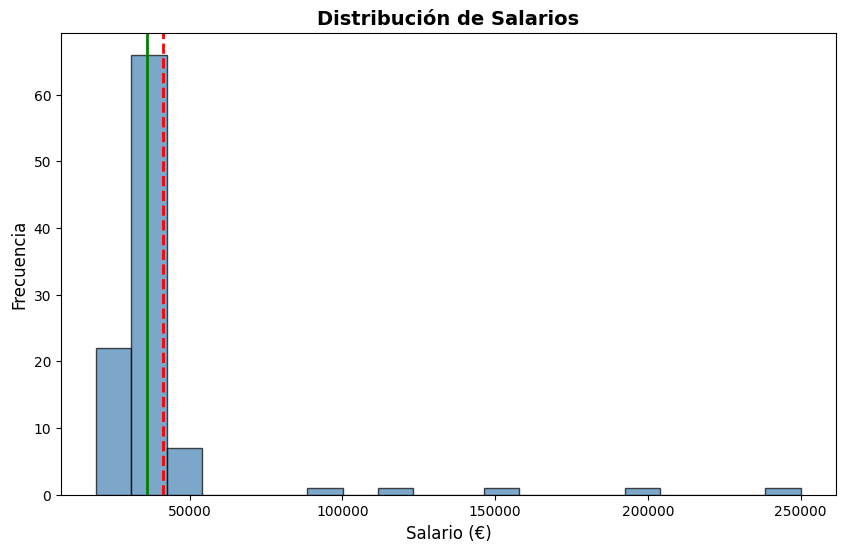

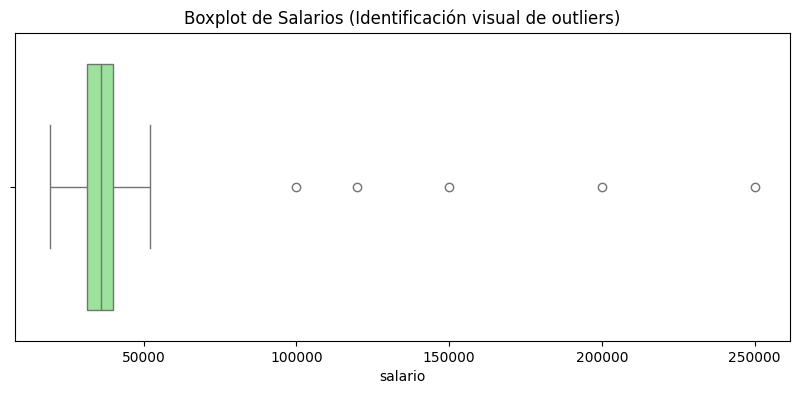


Rango IQR: 8583.58544898843
Rango normal: 52964.2931041633
Outliers detectados: 5

Valores de los outliers:
[100000. 120000. 150000. 200000. 250000.]


In [ ]:
# Crear el DataFrame
rng = np.random.default_rng(42)
salarios_normales = rng.normal(35000, 8000, 95)
salarios_outliers = np.array([100000, 120000, 150000, 200000, 250000])
salarios = np.concatenate([salarios_normales, salarios_outliers])

df_salarios = pd.DataFrame({'salario': salarios})

plt.figure(figsize=(10, 6))
plt.hist(df_salarios['salario'], bins=20, color='steelblue', edgecolor='black', alpha=0.7)

# Media y mediana
plt.axvline(df_salarios['salario'].mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {df_salarios["salario"].mean():.1f}')
plt.axvline(df_salarios['salario'].median(), color='green', linestyle='-', linewidth=2, label=f'Mediana: {df_salarios["salario"].median():.1f}')

plt.xlabel('Salario (€)', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.title('Distribución de Salarios', fontsize=14, fontweight='bold')

# Boxplot
plt.figure(figsize=(10, 4))
sns.boxplot(x=df_salarios['salario'], color='lightgreen')
plt.title('Boxplot de Salarios (Identificación visual de outliers)')
plt.show()

# Identificación Outliers con el método IQR
# Calcular Q1, Q3 e IQR
Q1 = df_salarios['salario'].quantile(0.25)
Q3 = df_salarios['salario'].quantile(0.75)
IQR = Q3 - Q1
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = df_salarios[(df_salarios['salario'] < limite_inferior) | (df_salarios['salario'] > limite_superior)]

print(f"{turquesa}\nRango IQR:{reset} {IQR}")
print(f"{turquesa}Rango normal: {reset}{limite_superior}")
print(f"{turquesa}Outliers detectados: {reset}{len(outliers)}")
print(f"{turquesa}\nValores de los outliers:{reset}")
print(outliers['salario'].values)

## 🟡 Ejercicio 6: Limpieza y Estandarización de Texto

Tienes un dataset con datos de texto inconsistentes:

```python
df_texto = pd.DataFrame({
    'ciudad': ['Madrid', 'madrid', 'MADRID', '  Barcelona  ', 'barcelna', 
               'Valencia', 'VALENCIA', ' Sevilla', 'sevila', 'Bilbao'],
    'categoria': ['electrónica', 'ROPA', 'Hogar', 'electrónica', 'ropa',
                  'HOGAR', 'Electronica', 'ropa', 'hogar', 'Electronica'],
    'ventas': [1500, 800, 1200, 950, 750, 1100, 1300, 600, 900, 1050]
})
```

**Tareas:**
1. Elimina espacios en blanco al inicio y final de 'ciudad'
2. Convierte 'ciudad' a formato capitalizado (primera letra mayúscula)
3. Corrige los errores tipográficos ('barcelna' → 'Barcelona', 'sevila' → 'Sevilla')
4. Estandariza 'categoria' a formato capitalizado
5. Corrige 'Electronica' a 'Electrónica' (con tilde)
6. Muestra las ventas totales por ciudad (después de limpiar)
7. Muestra las ventas totales por categoría (después de limpiar)

In [ ]:
# Crear el DataFrame
df_texto = pd.DataFrame({
    'ciudad': ['Madrid', 'madrid', 'MADRID', '  Barcelona  ', 'barcelna', 
               'Valencia', 'VALENCIA', ' Sevilla', 'sevila', 'Bilbao'],
    'categoria': ['electrónica', 'ROPA', 'Hogar', 'electrónica', 'ropa',
                  'HOGAR', 'Electronica', 'ropa', 'hogar', 'Electronica'],
    'ventas': [1500, 800, 1200, 950, 750, 1100, 1300, 600, 900, 1050]
})

print(f"{turquesa}Dataframe inicial{reset}")
print((df_texto).value_counts())

# Eliminar espacios en blanco al inicio y final de 'ciudad'
df_texto['ciudad_limpia'] = df_texto['ciudad'].str.strip()

# Conversión 'ciudad' a formato capitalizado
df_texto['ciudad_limpia'] = df_texto['ciudad_limpia'].str.lower() 
df_texto['ciudad_limpia'] = df_texto['ciudad_limpia'].str.title() 

# correción errores tipográficos
correcciones = {
 'Barcelna': 'Barcelona',
 'Sevila': 'Sevilla'
}
df_texto['ciudad_limpia'] = df_texto['ciudad_limpia'].replace(correcciones)


# Estandarizar 'categoria' a formato capitalizado
df_texto['categoria_limpia'] = df_texto['categoria'].str.strip()
df_texto['categoria_limpia'] = df_texto['categoria_limpia'].str.lower() 
df_texto['categoria_limpia'] = df_texto['categoria_limpia'].str.title() 

# Corregir 'Electrónica'
correccion = {
 'Electronica': 'Electrónica'
}
df_texto['categoria_limpia'] = df_texto['categoria_limpia'].replace(correccion) 

# Mostrar ventanas totales por ciudad y por categoría ya corregidas
print(f"{turquesa}\nColumna 'ciudad' corregida{reset}")
print(df_texto['ciudad_limpia'].value_counts())
print(f"{turquesa}\nColumna 'categoría' corregida{reset}")
print(df_texto['categoria_limpia'].value_counts())

Dataframe inicial
ciudad         categoria    ventas
  Barcelona    electrónica  950       1
 Sevilla       ropa         600       1
Bilbao         Electronica  1050      1
MADRID         Hogar        1200      1
Madrid         electrónica  1500      1
VALENCIA       Electronica  1300      1
Valencia       HOGAR        1100      1
barcelna       ropa         750       1
madrid         ROPA         800       1
sevila         hogar        900       1
Name: count, dtype: int64

Columna 'ciudad' corregida
ciudad_limpia
Madrid       3
Barcelona    2
Valencia     2
Sevilla      2
Bilbao       1
Name: count, dtype: int64

Columna 'categoría' corregida
categoria_limpia
Electrónica    4
Ropa           3
Hogar          3
Name: count, dtype: int64


## 🟡 Ejercicio 7: Análisis de Correlaciones

Crea un dataset con varias variables numéricas y analiza sus correlaciones:

```python
rng = np.random.default_rng(42)
n = 200

# Creamos variables con diferentes niveles de correlación
experiencia = rng.uniform(0, 20, n)
educacion = rng.integers(1, 5, n)  # 1=Secundaria, 2=Grado, 3=Master, 4=Doctorado
salario = 20000 + experiencia * 2000 + educacion * 5000 + rng.normal(0, 5000, n)
horas_trabajo = 40 + rng.normal(0, 5, n)
satisfaccion = 5 + 0.3 * experiencia - 0.1 * horas_trabajo + rng.normal(0, 1, n)
satisfaccion = np.clip(satisfaccion, 1, 10)

df_correlaciones = pd.DataFrame({
    'experiencia': experiencia,
    'educacion': educacion,
    'salario': salario,
    'horas_trabajo': horas_trabajo,
    'satisfaccion': satisfaccion
})
```

**Tareas:**
1. Calcula la matriz de correlación
2. Crea un **heatmap** de la matriz de correlación con `sns.heatmap()`
3. Identifica las dos variables con mayor correlación positiva
4. Identifica las dos variables con mayor correlación negativa
5. Crea un **scatter plot** entre experiencia y salario, añadiendo una línea de tendencia


MATRIZ DE CORRELACIÓN
               experiencia  educacion  salario  horas_trabajo  satisfaccion
experiencia           1.00      -0.04     0.81           0.09          0.83
educacion            -0.04       1.00     0.42          -0.06          0.03
salario               0.81       0.42     1.00           0.08          0.70
horas_trabajo         0.09      -0.06     0.08           1.00         -0.19
satisfaccion          0.83       0.03     0.70          -0.19          1.00


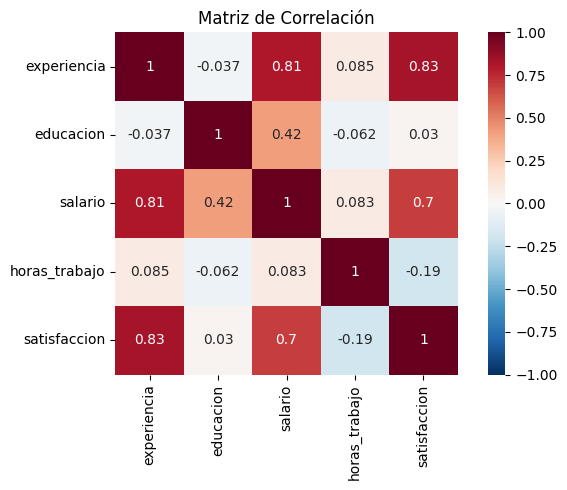

INTERPRETACION
Mayor correlación positiva: 'experiencia' y 'satisfaccion'
Mayor correlación negativa: 'horas_trabajo' y 'satisfaccion'



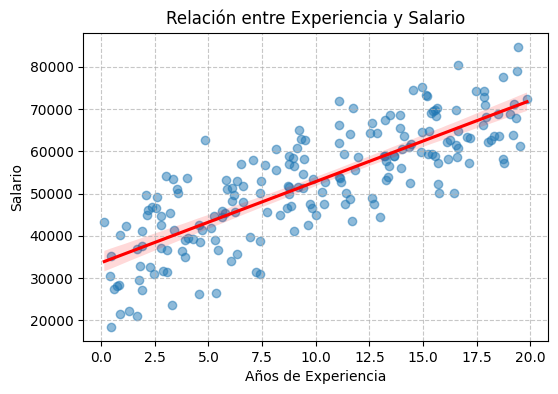

In [ ]:
# Crear el DataFrame
rng = np.random.default_rng(42)
n = 200

experiencia = rng.uniform(0, 20, n)
educacion = rng.integers(1, 5, n)
salario = 20000 + experiencia * 2000 + educacion * 5000 + rng.normal(0, 5000, n)
horas_trabajo = 40 + rng.normal(0, 5, n)
satisfaccion = 5 + 0.3 * experiencia - 0.1 * horas_trabajo + rng.normal(0, 1, n)
satisfaccion = np.clip(satisfaccion, 1, 10)

df_correlaciones = pd.DataFrame({
    'experiencia': experiencia,
    'educacion': educacion,
    'salario': salario,
    'horas_trabajo': horas_trabajo,
    'satisfaccion': satisfaccion
})

# Matríz de correlación
correlaciones = df_correlaciones.corr()
print(f"\n{turquesa}MATRIZ DE CORRELACIÓN{reset}")
print(correlaciones.round(2))

# Crear un heatmap
plt.figure(figsize=(7, 5))

sns.heatmap(correlaciones, 
 annot=True,
 cmap='RdBu_r',
 center=0,
 vmin=-1, vmax=1,
 square=True)

plt.title('Matriz de Correlación')
plt.tight_layout()  
plt.show()

# Identificar las dos variables con mayor correlación positiva
# Identificar las dos variables con mayor correlación negativa
print(f"{turquesa}INTERPRETACION{reset}")
print(f"{turquesa}Mayor correlación positiva:{reset} 'experiencia' y 'satisfaccion'")
print(f"{turquesa}Mayor correlación negativa: {reset}'horas_trabajo' y 'satisfaccion'")
print()
# Crear un satter-plot
# 5. Scatter plot entre experiencia y salario
plt.figure(figsize=(6, 4))
sns.regplot(data=df_correlaciones, x='experiencia', y='salario', 
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'})

plt.title('Relación entre Experiencia y Salario')
plt.xlabel('Años de Experiencia')
plt.ylabel('Salario')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## 🟡 Ejercicio 8: Tratamiento de Outliers

Trabaja con datos que contienen valores extremos:

```python
rng = np.random.default_rng(42)
# Datos con outliers intencionados
df_outliers = pd.DataFrame({
    'producto': ['P' + str(i) for i in range(1, 21)],
    'precio': [20, 25, 22, 28, 24, 500, 21, 26, -10, 23,
               27, 19, 25, 30, 22, 400, 24, 28, 26, -5],
    'unidades_vendidas': [100, 150, 120, 80, 200, 5, 130, 90, 110, 140,
                          95, 180, 160, 70, 145, 3, 125, 105, 155, 85]
})
```

**Tareas:**
1. Identifica outliers en 'precio' usando el método IQR
2. Identifica outliers lógicos (precios negativos o mayores a 100€)
3. **Opción A**: Elimina las filas con outliers
4. **Opción B**: Reemplaza los outliers por los límites (winsorización)
5. **Opción C**: Reemplaza los outliers por la mediana
6. Compara las estadísticas antes y después de cada tratamiento

In [ ]:
# Crear el DataFrame
rng = np.random.default_rng(42)
df_outliers = pd.DataFrame({
    'producto': ['P' + str(i) for i in range(1, 21)],
    'precio': [20, 25, 22, 28, 24, 500, 21, 26, -10, 23,
               27, 19, 25, 30, 22, 400, 24, 28, 26, -5],
    'unidades_vendidas': [100, 150, 120, 80, 200, 5, 130, 90, 110, 140,
                          95, 180, 160, 70, 145, 3, 125, 105, 155, 85]
})

# Identificar outliers en 'precio' con el método IQR
print(f"\n{turquesa}MÉTODO IQR{reset}")
Q1 = df_outliers['precio'].quantile(0.25)
Q3 = df_outliers['precio'].quantile(0.75)
IQR = Q3 - Q1
limite_inf = Q1 - 1.5 * IQR
limite_sup = Q3 + 1.5 * IQR

print(f"Rango aceptable: {limite_inf:.2f}€ - {limite_sup:.2f}€")
outliers_iqr = df_outliers[(df_outliers['precio'] < limite_inf) | (df_outliers['precio'] > limite_sup)]
print(f"Outliers: {len(outliers_iqr)}")

# Identificar outliers lógicos (precios negativos o > a 100€)
outliers_logicos = df_outliers[(df_outliers['precio'] < 0) | (df_outliers['precio'] > 100)]
print(f"\n{turquesa}OUTLIERS DETECTADOS:{reset} {len(outliers_logicos)}")
print(outliers_logicos)

# Eliminar las filas con outliers
df_sin_outliers = df_outliers[(df_outliers['precio'] >0) & (df_outliers['precio'] <= 100)]
print(f"\n{turquesa}ELIMINAR OUTLIERS: {reset}{len(df_sin_outliers)} filas restantes")

# Reemplazar los outliers por los límites (winsorización)
df_winsorizado = df_outliers.copy()
df_winsorizado.loc[df_winsorizado['precio'] < 0, 'precio'] = 0
df_winsorizado.loc[df_winsorizado['precio'] > 100, 'precio'] = 100
print(f"\n{turquesa}LIMITAR VALORES: precios entre 0 y 100{reset}")
print(df_winsorizado)

# Reemplazr los outliers por la mediana
df_mediana = df_outliers.copy()
df_mediana['precio'] = df_mediana['precio'].astype(float)
mediana = df_mediana['precio'].median()
df_mediana.loc[(df_mediana['precio'] < 0) | (df_mediana['precio'] > 100), 'precio'] = mediana
print(f"{turquesa}\nREEMPLAZAR POR MEDIANA ({mediana:.2f}€){reset}")
print(df_mediana)

# Comparar las estadísticas antes y después de cada tratamiento
comparativa = pd.DataFrame({
    'Original': df_outliers['precio'].describe(),
    '1. Eliminados (IQR)': df_sin_outliers['precio'].describe(),
    '2. Limitados (0-100)': df_winsorizado['precio'].describe(),
    '3. Reemplazo Mediana': df_mediana['precio'].describe()
})

print(f"\n{turquesa}COMPARATIVA DE TRATAMIENTOS{reset}")
print(comparativa.round(2)) 


MÉTODO IQR
Rango aceptable: 13.50€ - 35.50€
Outliers: 4

OUTLIERS DETECTADOS: 4
   producto  precio  unidades_vendidas
5        P6     500                  5
8        P9     -10                110
15      P16     400                  3
19      P20      -5                 85

ELIMINAR OUTLIERS: 16 filas restantes

LIMITAR VALORES: precios entre 0 y 100
   producto  precio  unidades_vendidas
0        P1      20                100
1        P2      25                150
2        P3      22                120
3        P4      28                 80
4        P5      24                200
5        P6     100                  5
6        P7      21                130
7        P8      26                 90
8        P9       0                110
9       P10      23                140
10      P11      27                 95
11      P12      19                180
12      P13      25                160
13      P14      30                 70
14      P15      22                145
15      P16     100  

## 🔴 Ejercicio 9: Análisis Exploratorio Completo (EDA)

Realiza un EDA completo del siguiente dataset de ventas:

```python
rng = np.random.default_rng(42)
n = 500

df_ventas_eda = pd.DataFrame({
    'fecha': pd.date_range('2024-01-01', periods=n, freq='D'),
    'tienda': np.random.choice(['Madrid', 'Barcelona', 'Valencia', 'Sevilla'], n),
    'categoria': np.random.choice(['Electrónica', 'Ropa', 'Hogar', 'Deportes'], n),
    'ventas': np.random.exponential(500, n) + 100,
    'unidades': rng.integers(1, 50, n),
    'descuento': np.random.choice([0, 5, 10, 15, 20], n)
})

# Introducir algunos valores nulos
df_ventas_eda.loc[np.random.choice(n, 20), 'ventas'] = np.nan
df_ventas_eda.loc[np.random.choice(n, 15), 'descuento'] = np.nan
```

**Tareas:**
1. **Exploración inicial**: dimensiones, tipos de datos, primeras filas
2. **Análisis de nulos**: porcentaje y decisión de tratamiento
3. **Estadísticas descriptivas** de variables numéricas
4. **Análisis de variables categóricas**: frecuencias por tienda y categoría
5. **Visualizaciones**:
   - Histograma de ventas
   - Boxplot de ventas por tienda
   - Gráfico de barras de ventas totales por categoría
6. **Análisis temporal**: ventas por mes
7. **Detectar outliers** en ventas y decidir qué hacer con ellos
8. **Conclusiones**: 3 hallazgos principales del análisis

In [34]:
# Crear el DataFrame
rng = np.random.default_rng(42)
n = 500

df_ventas_eda = pd.DataFrame({
    'fecha': pd.date_range('2024-01-01', periods=n, freq='D'),
    'tienda': np.random.choice(['Madrid', 'Barcelona', 'Valencia', 'Sevilla'], n),
    'categoria': np.random.choice(['Electrónica', 'Ropa', 'Hogar', 'Deportes'], n),
    'ventas': np.random.exponential(500, n) + 100,
    'unidades': rng.integers(1, 50, n),
    'descuento': np.random.choice([0, 5, 10, 15, 20], n)
})

# Introducir algunos valores nulos
# Aseguramos que las columnas acepten nulos (deben ser float)
df_ventas_eda['ventas'] = df_ventas_eda['ventas'].astype(float)
df_ventas_eda['descuento'] = df_ventas_eda['descuento'].astype(float)

df_ventas_eda.loc[df_ventas_eda.sample(n=20).index, 'ventas'] = np.nan
df_ventas_eda.loc[df_ventas_eda.sample(n=15).index, 'descuento'] = np.nan

# Tu código aquí - EXPLORACIÓN INICIAL
print(f"\n{turquesa}Tamaño (filas, columnas){reset}", df_ventas_eda.shape)
print(f"\n{turquesa}Columnas{reset}")
print(list(df_ventas_eda.columns))

print(f"\n{turquesa}Tipos de datos{reset}")
print(df_ventas_eda.dtypes)

print(f"\n{turquesa}Primeras filas (head){reset}")
print(df_ventas_eda.head())

print(f"\n{turquesa}Muestra aleatoria (5 filas){reset}")
print(df_ventas_eda.sample(5, random_state=42))


Tamaño (filas, columnas) (500, 6)

Columnas
['fecha', 'tienda', 'categoria', 'ventas', 'unidades', 'descuento']

Tipos de datos
fecha        datetime64[ns]
tienda               object
categoria            object
ventas              float64
unidades              int64
descuento           float64
dtype: object

Primeras filas (head)
       fecha     tienda    categoria      ventas  unidades  descuento
0 2024-01-01     Madrid        Hogar  357.763719         5       20.0
1 2024-01-02  Barcelona        Hogar  337.911724        38       10.0
2 2024-01-03     Madrid     Deportes  882.113845        33       10.0
3 2024-01-04     Madrid  Electrónica  456.531637        22       20.0
4 2024-01-05    Sevilla        Hogar  656.707467        22       10.0

Muestra aleatoria (5 filas)
         fecha     tienda    categoria      ventas  unidades  descuento
361 2024-12-27  Barcelona     Deportes  226.857414        44        5.0
73  2024-03-14     Madrid  Electrónica  126.540728         7        0.0
3

In [ ]:
# Tu código aquí - ANÁLISIS DE NULOS Y TRATAMIENTO
nulos_totales = df_ventas_eda.isnull().sum()
nulos_pct = (df_ventas_eda.isnull().sum() / len(df_ventas_eda)) * 100

df_nulos = pd.DataFrame({
    'Cant. Nulos': nulos_totales,
    'Porcentaje (%)': nulos_pct
})
print(f"{turquesa}\nANÁLISIS DE VALORES NULOS{reset}")
print(df_nulos[df_nulos['Cant. Nulos'] > 0])

#Tratamiento
df_limpio = df_ventas_eda.copy()

# Usamos la mediana porque las ventas suelen tener outliers que inflan la media
mediana_ventas = df_limpio['ventas'].median()
df_limpio['ventas'] = df_limpio['ventas'].fillna(mediana_ventas)

# Tratamiento para 'descuento': Imputación por Cero
# En descuentos, lo más lógico es asumir que si es nulo es porque no hubo descuento
df_limpio['descuento'] = df_limpio['descuento'].fillna(0)

print(f"\n{turquesa}TRATAMIENTO COMPLETADO{reset}")
print(f"{turquesa}Nulos restantes:{reset} {df_limpio.isnull().sum().sum()}")



ANÁLISIS DE VALORES NULOS
           Cant. Nulos  Porcentaje (%)
ventas              19             3.8
descuento           15             3.0

TRATAMIENTO COMPLETADO
Nulos restantes: 0



ESTADÍSTICAS DESCRIPTIVAS (DATOS LIMPIOS)
        ventas  unidades  descuento
count   500.00    500.00     500.00
mean    604.96     24.97      10.18
std     471.38     14.01       7.08
min     100.90      1.00       0.00
25%     274.91     13.00       5.00
50%     469.71     25.00      10.00
75%     775.17     37.00      15.00
max    2935.34     49.00      20.00


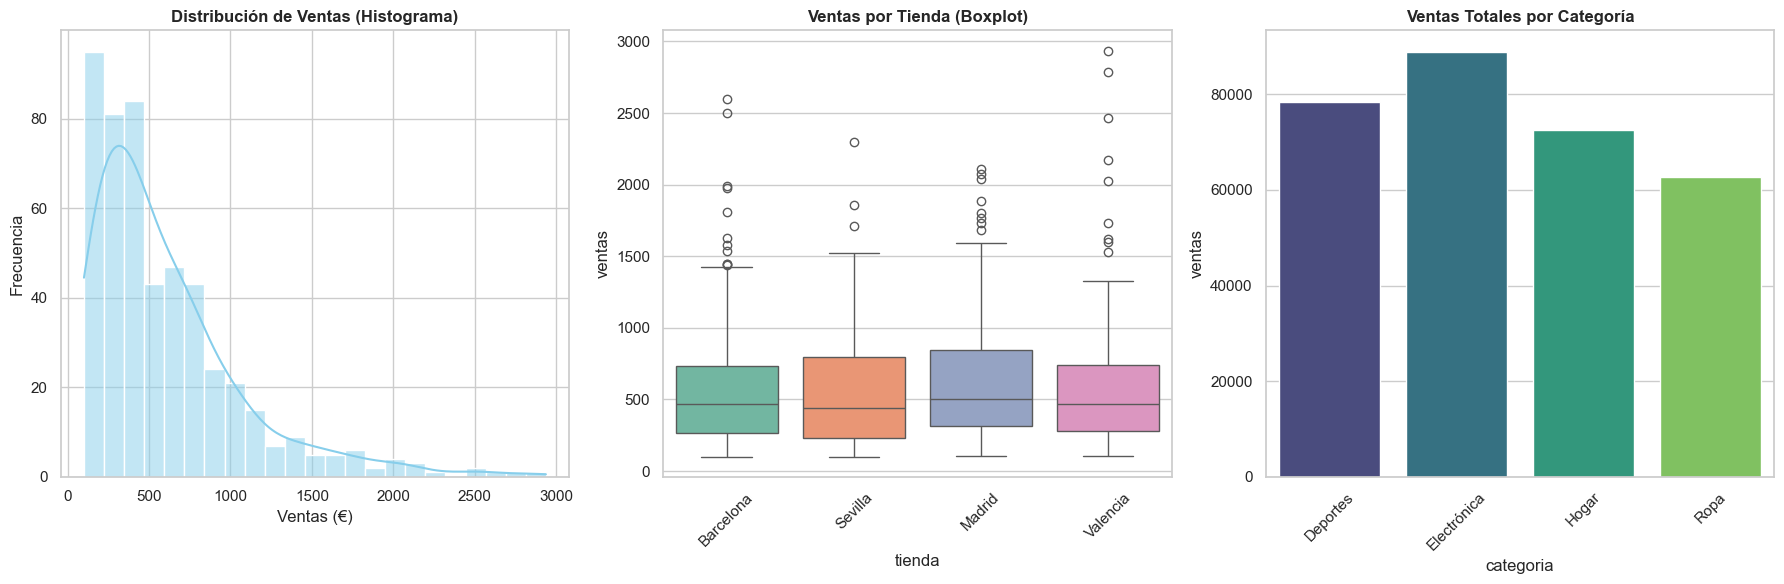

In [31]:
# Tu código aquí - ESTADÍSTICAS Y VISUALIZACIONES

print(f"{turquesa}\nESTADÍSTICAS DESCRIPTIVAS (DATOS LIMPIOS){reset}")
print(df_limpio[['ventas', 'unidades', 'descuento']].describe().round(2))

# Configuración estética global
sns.set_theme(style="whitegrid")
plt.figure(figsize=(18, 6))

# HISTOGRAMA DE VENTAS
plt.subplot(1, 3, 1)
sns.histplot(data=df_limpio, x='ventas', kde=True, color='skyblue')
plt.title('Distribución de Ventas (Histograma)', fontweight='bold')
plt.xlabel('Ventas (€)')
plt.ylabel('Frecuencia')

# BOXPLOT DE VENTAS POR TIENDA
plt.subplot(1, 3, 2)
sns.boxplot(data=df_limpio, x='tienda', y='ventas', palette='Set2', hue='tienda', legend=False)
plt.title('Ventas por Tienda (Boxplot)', fontweight='bold')
plt.xticks(rotation=45)

# GRÁFICO DE BARRAS: VENTAS TOTALES POR CATEGORÍA
plt.subplot(1, 3, 3)
ventas_cat = df_limpio.groupby('categoria')['ventas'].sum().reset_index()
sns.barplot(data=ventas_cat, x='categoria', y='ventas', palette='viridis', hue='categoria', legend=False)
plt.title('Ventas Totales por Categoría', fontweight='bold')
plt.xticks(rotation=45)

# Ajuste final de layout para que no se solapen los textos
plt.tight_layout()
plt.show()

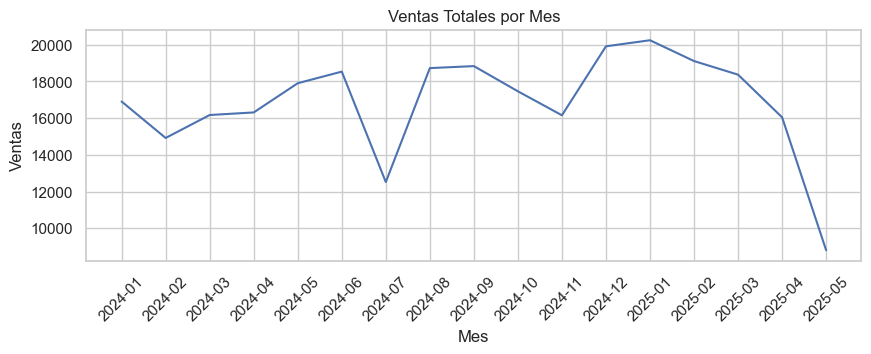

MÉTODO IQR 
Rango aceptable: -2977.34€ - 3993.64€
Outliers: 0

CONCLUSIONES DEL ANÁLISIS EXPLORATORIO
1- Las ventas presentan una alta variabilidad y una distribución asimétrica positiva, con muchos valores moderados y algunos valores extremos elevados, lo cual es típico en datos de ventas reales.
2- El análisis temporal muestra fluctuaciones mensuales en las ventas, sin una tendencia claramente creciente o decreciente, lo que indica un comportamiento irregular a lo largo del tiempo.
3- El método IQR identifica un número elevado de outliers debido a la naturaleza exponencial de la variable ventas. Estos valores no se consideran errores, sino eventos de ventas excepcionalmente altas, por lo que se decide conservarlos para el análisis.


In [49]:
# Tu código aquí - ANÁLISIS TEMPORAL Y OUTLIERS
# ANÁLISIS TEMPORAL (Ventas por mes)
# Crear columna mes
df_ventas_eda['mes'] = df_ventas_eda['fecha'].dt.to_period('M')

# Ventas mensuales
ventas_mensuales = (
    df_ventas_eda
    .groupby('mes')['ventas']
    .sum()
    .reset_index()
)
print()
plt.figure(figsize=(10, 3))
plt.plot(ventas_mensuales['mes'].astype(str), ventas_mensuales['ventas'])
plt.xticks(rotation=45)
plt.title('Ventas Totales por Mes')
plt.xlabel('Mes')
plt.ylabel('Ventas')
plt.show()

# DETECTAR OUTLIERS DE VENTAS Y TRATAMIENTO
print(f"{turquesa}MÉTODO IQR {reset}")
Q1 = df_ventas_eda['ventas'].quantile(0.25)
Q3 = df_ventas_eda['ventas'].quantile(0.75)
IQR = Q1 - 1.5 * IQR
limite_inf = Q1 - 1.5 * IQR
limite_sup = Q3 + 1.5 * IQR

print(f"{turquesa}Rango aceptable: {reset}{limite_inf:.2f}€ - {limite_sup:.2f}€")
outliers_iqr = df_ventas_eda[(df_ventas_eda['ventas'] < limite_inf) | (df_ventas_eda['ventas'] > limite_sup)]
print(f"{turquesa}Outliers: {reset}{len(outliers_iqr)}")


# CONCLUSIONES (Hallazgos principales)
print(f"\n{turquesa}CONCLUSIONES DEL ANÁLISIS EXPLORATORIO{reset}")

print(
    "1- Las ventas presentan una alta variabilidad y una distribución asimétrica positiva, "
    "con muchos valores moderados y algunos valores extremos elevados, lo cual es típico en datos de ventas reales."
)

print(
    "2- El análisis temporal muestra fluctuaciones mensuales en las ventas, sin una tendencia "
    "claramente creciente o decreciente, lo que indica un comportamiento irregular a lo largo del tiempo."
)

print(
    "3- El método IQR identifica un número elevado de outliers debido a la naturaleza exponencial "
    "de la variable ventas. Estos valores no se consideran errores, sino eventos de ventas excepcionalmente altas, "
    "por lo que se decide conservarlos para el análisis."
)


## 🔴 Ejercicio 10: Limpieza de un Dataset Real (Caso Práctico)

Tienes un dataset "sucio" de clientes que necesita una limpieza completa:

```python
df_sucio = pd.DataFrame({
    'cliente_id': [1, 2, 3, 4, 5, 2, 6, 7, 8, 3, 9, 10],
    'nombre': ['  Ana García  ', 'CARLOS RUIZ', 'maría López', 'Pedro-Sánchez', 
               'laura MARTINEZ', 'CARLOS RUIZ', '  Juan Pérez', 'Sofia_Gomez',
               'Miguel Torres', 'maría López', 'Elena Castro', 'David  Moreno'],
    'email': ['ana@mail.com', 'carlos@MAIL.COM', 'maria@mail', 'pedro@mail.com',
              'laura@mail.com', 'carlos@MAIL.COM', 'juan@mail.com', None,
              'miguel@mail.com', 'maria@mail', 'elena@mail.com', 'david@mail.com'],
    'edad': [28, 35, 42, -5, 31, 35, 150, 29, 38, 42, 26, 45],
    'ciudad': ['Madrid', 'barcelona', 'VALENCIA', 'Madrid', 'Madird',
               'barcelona', 'Sevilla', 'Bilbao', 'Malaga', 'VALENCIA',
               'Madrid', 'barcelna'],
    'ingresos_mensuales': [2500, 3500, 4000, None, 2800, 3500, 3200, 2900,
                          -1000, 4000, 2600, 50000],
    'fecha_registro': ['2023-01-15', '2023/02/20', '15-03-2023', '2023-04-10',
                       '2023.05.25', '2023/02/20', '2023-06-30', '07/15/2023',
                       '2023-08-05', '15-03-2023', '2023-09-12', '2023-10-01']
})
```

**Tareas de Limpieza:**
1. **Duplicados**: Elimina clientes duplicados por 'cliente_id'
2. **Nombres**: Limpia espacios, estandariza formato (Nombre Apellido)
3. **Emails**: Normaliza a minúsculas, identifica emails inválidos (sin '@' o dominio)
4. **Edad**: Identifica valores imposibles (negativos o >120), reemplaza con NaN
5. **Ciudad**: Estandariza nombres, corrige errores tipográficos
6. **Ingresos**: Identifica outliers (negativos o extremadamente altos), decide tratamiento
7. **Fechas**: Unifica el formato de todas las fechas a 'YYYY-MM-DD'
8. **Reporte final**: Muestra un resumen del dataset limpio

In [16]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# colores
turquesa = '\033[38;5;44m'
reset = '\033[0m'

# Crear el DataFrame
df_sucio = pd.DataFrame({
    'cliente_id': [1, 2, 3, 4, 5, 2, 6, 7, 8, 3, 9, 10],
    'nombre': ['  Ana García  ', 'CARLOS RUIZ', 'maría López', 'Pedro-Sánchez', 
               'laura MARTINEZ', 'CARLOS RUIZ', '  Juan Pérez', 'Sofia_Gomez',
               'Miguel Torres', 'maría López', 'Elena Castro', 'David  Moreno'],
    'email': ['ana@mail.com', 'carlos@MAIL.COM', 'maria@mail', 'pedro@mail.com',
              'laura@mail.com', 'carlos@MAIL.COM', 'juan@mail.com', None,
              'miguel@mail.com', 'maria@mail', 'elena@mail.com', 'david@mail.com'],
    'edad': [28, 35, 42, -5, 31, 35, 150, 29, 38, 42, 26, 45],
    'ciudad': ['Madrid', 'barcelona', 'VALENCIA', 'Madrid', 'Madird',
               'barcelona', 'Sevilla', 'Bilbao', 'Malaga', 'VALENCIA',
               'Madrid', 'barcelna'],
    'ingresos_mensuales': [2500, 3500, 4000, None, 2800, 3500, 3200, 2900,
                          -1000, 4000, 2600, 50000],
    'fecha_registro': ['2023-01-15', '2023/02/20', '15-03-2023', '2023-04-10',
                       '2023.05.25', '2023/02/20', '2023-06-30', '07/15/2023',
                       '2023-08-05', '15-03-2023', '2023-09-12', '2023-10-01']
})

print(f"\n{turquesa}DATAFRAME ORIGINAL{reset}")
print(df_sucio)

# Tu código de limpieza aquí
# Duplicados: Eliminar clientes duplicados por 'cliente_id'.
print(f"{turquesa}\nTOTAL DE FILAS: {reset}{len(df_sucio)}")
duplicados = df_sucio.duplicated().sum()
print(f"{turquesa}FILAS DUPLICADAS: {reset}{duplicados}")

# Duplicados por "cliente_id"
duplicados = df_sucio.duplicated(subset=['cliente_id']).sum()
print(f"{turquesa}DUPLICADOS POR 'cliente_id':{reset} {duplicados}")

print(f"{turquesa}\nDATAFRAME CORREGIDO{reset}")
df_limpio = df_sucio.drop_duplicates(subset=['cliente_id'], keep='first').copy()
print(df_limpio)

# Nombres: Limpia espacios, estandarizar formato (Nombre Apellido)
df_limpio['nombre_limpio'] = df_limpio['nombre'].str.strip()
df_limpio['nombre_limpio'] = df_limpio['nombre_limpio'].str.lower()
df_limpio['nombre_limpio'] = df_limpio['nombre_limpio'].str.title()

print(f"{turquesa}\nFORMATO NOMBRES ESTANDARIZADO{reset}")
print(df_limpio['nombre_limpio'].value_counts())

# Emails: Normalizar a minúsculas, identificar emails inválidos (sin '@' o dominio)
df_limpio['email_limpio'] = df_limpio['email'].str.lower()
patron_email = r'^[\w\.-]+@[\w\.-]+\.\w+$'
df_limpio['email_valido'] = df_limpio['email_limpio'].str.match(patron_email)

correos_corregidos = df_limpio.loc[
    df_limpio['email_valido'] == True,
    ['cliente_id', 'email', 'email_limpio']
]
print(f"{turquesa}\nEMAILS CORREGIDOS{reset}")
print(correos_corregidos)



DATAFRAME ORIGINAL
    cliente_id          nombre            email  edad     ciudad  \
0            1    Ana García       ana@mail.com    28     Madrid   
1            2     CARLOS RUIZ  carlos@MAIL.COM    35  barcelona   
2            3     maría López       maria@mail    42   VALENCIA   
3            4   Pedro-Sánchez   pedro@mail.com    -5     Madrid   
4            5  laura MARTINEZ   laura@mail.com    31     Madird   
5            2     CARLOS RUIZ  carlos@MAIL.COM    35  barcelona   
6            6      Juan Pérez    juan@mail.com   150    Sevilla   
7            7     Sofia_Gomez             None    29     Bilbao   
8            8   Miguel Torres  miguel@mail.com    38     Malaga   
9            3     maría López       maria@mail    42   VALENCIA   
10           9    Elena Castro   elena@mail.com    26     Madrid   
11          10   David  Moreno   david@mail.com    45   barcelna   

    ingresos_mensuales fecha_registro  
0               2500.0     2023-01-15  
1              

In [19]:
# Continúa la limpieza aquí
# Edad: Identificar valores imposibles (negativos o > 120), reemplazar con NaN
df_limpio['edad_limpia'] = df_limpio['edad']
cond_edad_invalida = (df_limpio['edad_limpia'] < 0) | (df_limpio['edad_limpia'] > 120)
df_limpio.loc[cond_edad_invalida, 'edad_limpia'] = np.nan

print(f"{turquesa}\nEDADES INVÁLIDAS CORREGIDAS{reset}")
print(df_limpio.loc[cond_edad_invalida, ['edad']])

# Ciudad: Estandarizar nombres. Corregir errores tipográficos
df_limpio['ciudad_limpia'] = df_limpio['ciudad'].str.strip().str.lower()
     # Correcciones manuales
correcciones_ciudad = {'madird': 'madrid', 'barcelna': 'barcelona'}
df_limpio['ciudad_limpia'] = df_limpio['ciudad_limpia'].replace(correcciones_ciudad)
df_limpio['ciudad_limpia'] = df_limpio['ciudad_limpia'].str.title()

print(f"{turquesa}\nCIUDADES ESTANDARIZADAS{reset}")
print(df_limpio['ciudad_limpia'].value_counts())

# Ingresos: Identificar outliers (negativos o exrtremadamente altos). Decido el tratamiento
df_limpio['ingresos_limpios'] = df_limpio['ingresos_mensuales']
cond_ingresos_invalidos = (df_limpio['ingresos_limpios'] < 0) | (df_limpio['ingresos_limpios'] > 20000)
df_limpio.loc[cond_ingresos_invalidos, 'ingresos_limpios'] = np.nan

print(f"{turquesa}\nINGRESOS INVÁLIDOS / OUTLIERS{reset}")
print(df_limpio.loc[df_limpio['ingresos_limpios'].isna(), ['cliente_id', 'ingresos_mensuales']])


# Fechas: Unificar el formato de todas las fechas a 'YYY-MM-DD'
df_limpio['fecha_limpia'] = pd.to_datetime(df_sucio['fecha_registro'], errors='coerce', dayfirst=False).dt.strftime('%Y-%m-%d')

print(f"{turquesa}\nFECHAS NORMALIZADAS{reset}")
print(df_limpio[['fecha_registro', 'fecha_limpia']])


EDADES INVÁLIDAS CORREGIDAS
   edad
3    -5
6   150

CIUDADES ESTANDARIZADAS
ciudad_limpia
Madrid       4
Barcelona    2
Valencia     1
Sevilla      1
Bilbao       1
Malaga       1
Name: count, dtype: int64

INGRESOS INVÁLIDOS / OUTLIERS
    cliente_id  ingresos_mensuales
3            4                 NaN
8            8             -1000.0
11          10             50000.0

FECHAS NORMALIZADAS
   fecha_registro fecha_limpia
0      2023-01-15   2023-01-15
1      2023/02/20          NaN
2      15-03-2023          NaN
3      2023-04-10   2023-04-10
4      2023.05.25          NaN
6      2023-06-30   2023-06-30
7      07/15/2023          NaN
8      2023-08-05   2023-08-05
10     2023-09-12   2023-09-12
11     2023-10-01   2023-10-01


In [22]:
# Reporte final del dataset limpio
print(f"\n{turquesa}                              =========================================={reset}")
print(f"{turquesa}                                    REPORTE FINAL: DATASET LIMPIO{reset}")
print(f"{turquesa}                              =========================================={reset}")
print()
reporte = df_limpio[['cliente_id', 'nombre_limpio', 'email_limpio', 'edad_limpia', 'ciudad_limpia', 'ingresos_limpios', 'fecha_limpia']]
print(reporte.to_string(index=False))


                                    REPORTE FINAL: DATASET LIMPIO

 cliente_id  nombre_limpio    email_limpio  edad_limpia ciudad_limpia  ingresos_limpios fecha_limpia
          1     Ana García    ana@mail.com         28.0        Madrid            2500.0   2023-01-15
          2    Carlos Ruiz carlos@mail.com         35.0     Barcelona            3500.0          NaN
          3    María López      maria@mail         42.0      Valencia            4000.0          NaN
          4  Pedro-Sánchez  pedro@mail.com          NaN        Madrid               NaN   2023-04-10
          5 Laura Martinez  laura@mail.com         31.0        Madrid            2800.0          NaN
          6     Juan Pérez   juan@mail.com          NaN       Sevilla            3200.0   2023-06-30
          7    Sofia_Gomez            None         29.0        Bilbao            2900.0          NaN
          8  Miguel Torres miguel@mail.com         38.0        Malaga               NaN   2023-08-05
          9   Elena Cas

---

## ✅ Finalización del Boletín

Has completado los ejercicios de EDA y Limpieza de Datos. Los temas cubiertos incluyen:

- ✅ Exploración inicial de datasets (shape, dtypes, info, head)
- ✅ Estadísticas descriptivas (describe, mean, median, std)
- ✅ Detección y tratamiento de valores faltantes (isnull, fillna, dropna)
- ✅ Detección y eliminación de duplicados (duplicated, drop_duplicates)
- ✅ Visualización exploratoria (histogramas, boxplots, heatmaps)
- ✅ Limpieza y estandarización de texto (strip, lower, replace)
- ✅ Análisis de correlaciones
- ✅ Detección y tratamiento de outliers (método IQR)
- ✅ EDA completo de un dataset
- ✅ Limpieza integral de un dataset real

**Recuerda:** La limpieza de datos representa el 60-80% del trabajo en un proyecto de Data Science.
¡Dominar estas técnicas es fundamental!

**Siguientes pasos:**
- Practicar con datasets reales de Kaggle o datos.gob.es
- Revisar las soluciones proporcionadas
- Continuar con el Capítulo 2.2: Transformación de Datos